In [3]:
! pip install transformers datasets torch

In [4]:
! pip install scikit-learn
! pip install scikit-learn numpy pandas matplotlib

In [5]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

/home/ebratul/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
emotions = load_dataset("emotion")

In [7]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [8]:
emotions["train"][:5]

{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong',
  'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
  'i am feeling grouchy'],
 'label': [0, 0, 3, 2, 3]}

In [9]:
x = (emotions["train"].select(range(0, 32)))

In [10]:
x

Dataset({
    features: ['text', 'label'],
    num_rows: 32
})

In [11]:
# Convert the Dataset to  Pandas Dataframe
import pandas as pd

# df = emotions["train"].to_pandas()

df_train = pd.DataFrame(emotions["train"])

# emotions.set_format(type="pandas")
# df = emotions["train"][:]

df_train.head(3)

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3


In [12]:
df_train.shape

(16000, 2)

In [13]:
df_train['label'].unique()

array([0, 3, 2, 5, 4, 1])

In [14]:
for emotion in df_train["label"].unique():
    example = df_train[df_train["label"] == emotion]["text"].iloc[0]
    print(f"Class: {emotion} → Example: {example}")

Class: 0 → Example: i didnt feel humiliated
Class: 3 → Example: im grabbing a minute to post i feel greedy wrong
Class: 2 → Example: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Class: 5 → Example: ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny
Class: 4 → Example: i feel as confused about life as a teenager or as jaded as a year old man
Class: 1 → Example: i have been with petronas for years i feel that petronas has performed well and made a huge profit


In [15]:
train_data = emotions["train"]
test_data = emotions["validation"]

In [16]:
# Convert the Dataset to  Pandas Dataframe
import pandas as pd

# df = emotions["train"].to_pandas()

df_test = pd.DataFrame(emotions["validation"])

# emotions.set_format(type="pandas")
# df = emotions["train"][:]

df_test.head(3)

,text,label
0,im feeling quite sad and sorry for myself but ...,0
1,i feel like i am still looking at a blank canv...,0
2,i feel like a faithful servant,2


In [17]:
df_test.shape

(2000, 2)

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [17]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
model = AutoModel.from_pretrained('bert-base-uncased')
model.to(device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4227.66it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [18]:
def extract_features(text):
    with torch.no_grad():
        input = tokenizer(
            text,
            return_tensors='pt',
            truncation = True,
            padding = True,
            max_length = 128
        ).to(device)

        output = model(**input)
        hidden_states = output.last_hidden_state

        cls_hiddin_state = hidden_states[:,0,:]

        return cls_hiddin_state.cpu().numpy()

In [19]:
def batch_generator(dataset, batch_size = 64):
    
    dataset_size = len(dataset)

    for i in range(0, dataset_size, batch_size):
        end_index = min(i + batch_size, dataset_size)
        batch = dataset.select(range(i, end_index))
        batch_text = list(batch['text'])
        batch_label = list(batch['label'])
        batch_features = extract_features(batch_text)
        yield batch_features, batch_label

In [20]:
def collect_batches(generator):
    feature = []
    label = []

    for batch_feature, batch_label in generator:
        feature.append(batch_feature)
        label.extend(batch_label)   # ✅ FIX

    return np.vstack(feature), np.array(label)

In [21]:
train_generator = batch_generator(train_data, batch_size=64)
x_train, y_train = collect_batches(train_generator)

In [22]:
val_generator = batch_generator(test_data, batch_size=64)
x_val, y_val = collect_batches(val_generator)

In [23]:
print("Train shape:", x_train.shape, y_train.shape)
print("Val shape:", x_val.shape, y_val.shape)

Train shape: (16000, 768) (16000,)
Val shape: (2000, 768) (2000,)


In [24]:
# feature = []
# label = []

# for batch_feature, batch_label in train_generator:
#     feature.append(batch_feature)
#     label.append(batch_label)

In [25]:
# feature

In [26]:
model1 = LogisticRegression(max_iter=3000)
model1.fit(x_train, y_train)

y_pred = model1.predict(x_val)
accuracy = accuracy_score(y_val, y_pred)

print(f"validation accuracy : {accuracy}")

validation accuracy : 0.597


In [27]:
! pip install datasets transformers accelerate accelerate -U

In [28]:
import torch
print(torch.cuda.is_available())

False


In [29]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
from datasets import load_dataset

print("✅ Imports successful")

✅ Imports successful


In [30]:
# Tokenization function
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [31]:
import pandas as pd

In [32]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
import torch

# Load dataset
emotions = load_dataset("emotion")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Apply tokenization
emotions_encoded = emotions.map(tokenize, batched=True)

# Split dataset
train_data = emotions_encoded['train']
val_data = emotions_encoded['validation']

# Remove text column
train_data = train_data.remove_columns(['text'])
val_data = val_data.remove_columns(['text'])


# print(train_data["text"])


# Convert to torch format
train_data.set_format("torch")
val_data.set_format("torch")

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load model
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=6
)

model.to(device)


Using device: cpu


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11127.55it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider t

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [33]:
# df = pd.DataFrame(train_data)
# df.head(3)

In [34]:
! pip install transformers datasets torch accelerate

In [35]:
! pip install --upgrade transformers

In [36]:
# pip uninstall transformers -y
# pip install transformers==4.44.2
import transformers
print(transformers.__version__)

5.3.0


In [37]:
# from transformers import TrainingArguments

# training_args = TrainingArguments(
#     eval_strategy="epoch",   # প্রতিটি epoch শেষে model evaluate করবে
#     per_device_train_batch_size=32,   # প্রতি GPU/CPU device এ 4 টা sample per batch
#     per_device_eval_batch_size=32,    # evaluation batch size
#     num_train_epochs=2,              # মোট 1 বার dataset দেখাবে
#     weight_decay=0.01,               # L2 regularization (overfitting কমাতে)
#     logging_dir="/home/ebratul/Documents/code/mubarak",            # log file save path
#     logging_steps=10,                # 10 step পর পর log save হবে
#     dataloader_pin_memory=True,      # memory optimization option
#     disable_tqdm=False,              # notebook এ progress bar bug এড়াতে
#     output_dir="./results"           # training শেষে model save হবে এখানে

# )

In [38]:
# import torch
# import accelerate
# import transformers

# print(torch.__version__)
# print(accelerate.__version__)
# print(transformers.__version__)

In [39]:
# import accelerate
# print(accelerate.__version__)
# import sys
# print(sys.executable)
# import sys
# !{sys.executable} -m pip uninstall -y accelerate
# !{sys.executable} -m pip install accelerate --no-cache-dir
# !{sys.executable} -m pip install -U transformers

In [40]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cpu
False


In [41]:
# pip uninstall torch torchvision torchaudio -y
# নতুন environment Python 3.11 দিয়ে
# python3.11 -m venv ~/Documents/code/mubarak/venv311
# source ~/Documents/code/mubarak/venv311/bin/activate
# pip install --upgrade pip
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu12x
import torch
print("CUDA available:", torch.cuda.is_available())
# print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: False


In [42]:
# import torch

# print("PyTorch version:", torch.__version__)
# print("CUDA available:", torch.cuda.is_available())

# if torch.cuda.is_available():
#     print("GPU device name:", torch.cuda.get_device_name(0))
#     print("CUDA version:", torch.version.cuda)

In [43]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    logging_steps=100,
    weight_decay=0.01,
    fp16=True,   # if GPU available
    dataloader_num_workers=2,
    disable_tqdm=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data
)

trainer.train()      # Train চলবে
trainer.evaluate()   # Evaluate চলবে

/home/ebratul/myenv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'loss': '1.238', 'grad_norm': '7.536', 'learning_rate': '4.505e-05', 'epoch': '0.1'}
{'loss': '0.5814', 'grad_norm': '14.06', 'learning_rate': '4.005e-05', 'epoch': '0.2'}
{'loss': '0.3641', 'grad_norm': '8.483', 'learning_rate': '3.505e-05', 'epoch': '0.3'}
{'loss': '0.304', 'grad_norm': '9.863', 'learning_rate': '3.005e-05', 'epoch': '0.4'}
{'loss': '0.2771', 'grad_norm': '5.612', 'learning_rate': '2.505e-05', 'epoch': '0.5'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.31it/s]


{'loss': '0.2336', 'grad_norm': '17.65', 'learning_rate': '2.005e-05', 'epoch': '0.6'}
{'loss': '0.1939', 'grad_norm': '35.81', 'learning_rate': '1.505e-05', 'epoch': '0.7'}
{'loss': '0.1964', 'grad_norm': '18.32', 'learning_rate': '1.005e-05', 'epoch': '0.8'}
{'loss': '0.2172', 'grad_norm': '2.128', 'learning_rate': '5.05e-06', 'epoch': '0.9'}
{'loss': '0.1775', 'grad_norm': '3.135', 'learning_rate': '5e-08', 'epoch': '1'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.79it/s]
/home/ebratul/myenv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.1485', 'eval_runtime': '131.4', 'eval_samples_per_second': '15.22', 'eval_steps_per_second': '0.951', 'epoch': '1'}
{'train_runtime': '4114', 'train_samples_per_second': '3.89', 'train_steps_per_second': '0.243', 'train_loss': '0.3783', 'epoch': '1'}
{'eval_loss': '0.1485', 'eval_runtime': '131.7', 'eval_samples_per_second': '15.18', 'eval_steps_per_second': '0.949', 'epoch': '1'}


{'eval_loss': 0.14848807454109192,
 'eval_runtime': 131.7136,
 'eval_samples_per_second': 15.184,
 'eval_steps_per_second': 0.949,
 'epoch': 1.0}

In [44]:
prediction = trainer.predict(val_data)
y_pred = prediction.predictions.argmax(axis=1)
y_val = prediction.label_ids

accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy = {accuracy}")

Accuracy = 0.94


In [45]:
from sklearn.metrics import precision_recall_fscore_support

precesion, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average = 'weighted')

print(f"precision = {precesion}")
print(f"Recall = {recall}")
print(f"F1- Score = {f1}")

precision = 0.9405280206162637
Recall = 0.94
F1- Score = 0.9401191949396593


In [46]:
from datasets import load_dataset

dataset = load_dataset("emotion")

# train split use করবো
data = dataset['train']

# 1️⃣ Number of classes
labels = data.features['label'].names
print("Number of classes:", len(labels))

# 2️⃣ Class names
print("Class names:", labels)

# 3️⃣ Example
print("\nExamples:\n")

for i, label_name in enumerate(labels):
    for item in data:
        if item['label'] == i:
            print(f"Class: {label_name}")
            print(f"Example: {item['text']}")
            print("-" * 50)
            break

Number of classes: 6
Class names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Examples:

Class: sadness
Example: i didnt feel humiliated
--------------------------------------------------
Class: joy
Example: i have been with petronas for years i feel that petronas has performed well and made a huge profit
--------------------------------------------------
Class: love
Example: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
--------------------------------------------------
Class: anger
Example: im grabbing a minute to post i feel greedy wrong
--------------------------------------------------
Class: fear
Example: i feel as confused about life as a teenager or as jaded as a year old man
--------------------------------------------------
Class: surprise
Example: ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny
------------------------------------------------

In [47]:
! pip install seaborn

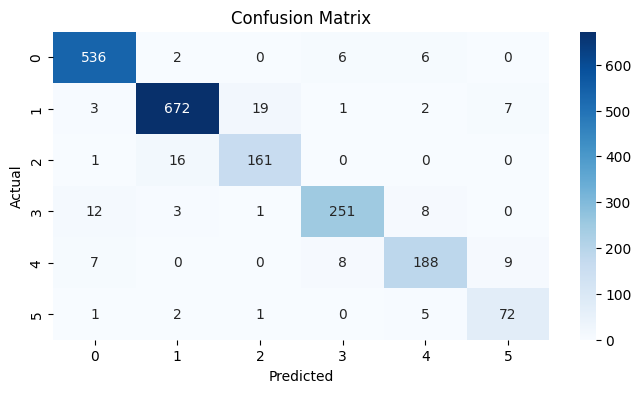

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sb
import matplotlib.pyplot as plt


plt.figure(figsize=(8,4))
cm = confusion_matrix(y_val, y_pred)
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [49]:
# TP (True Positive): class-কে সঠিকভাবে predict করা হয়েছে
# FP (False Positive): অন্য class কে ভুল predict করে target class বলা হয়েছে
# FN (False Negative): target class কে অন্য class বলা হয়েছে

# 🔹 Precision (নির্ভুলতা) :এক class predict করা হলে সেটি কতটা সঠিক ছিল তা বোঝায়।
#recall : এক class-এর সত্যিকারের উদাহরণগুলোর মধ্যে কতগুলো সঠিকভাবে predict করা হয়েছে।
# F1 Score:Precision এবং Recall-এর harmonic mean, যা balance করে।

In [50]:
! pip install nbformat

In [51]:
import os
print(os.getcwd())
print(os.listdir("/home/ebratul/Documents/code/mubarak"))

/home/ebratul/Documents/code/mubarak
['.venv', '.vscode', 'Text_classification_with_transformer.ipynb', 'myenv', 'results']


In [52]:
import nbformat

notebook_path = "/home/ebratul/Documents/code/mubarak/Text_classification_with_transformer.ipynb"

# Open notebook
with open(notebook_path, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

# Remove widgets metadata
for cell in nb.cells:
    if "metadata" in cell and "widgets" in cell.metadata:
        cell.metadata.pop("widgets", None)

# Save notebook back
with open(notebook_path, "w", encoding="utf-8") as f:
    nbformat.write(nb, f)

print("Widgets metadata removed successfully ✅")

Widgets metadata removed successfully ✅


In [55]:
! pip install sentencepiece

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
# inputs = {k: v.to(device) for k, v in inputs.items()}

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [63]:
trainer.save_model("results")
tokenizer.save_pretrained("results")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.91it/s]


('results/tokenizer_config.json', 'results/tokenizer.json')

In [65]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load model & tokenizer
model_path = "results"

tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
model = AutoModelForSequenceClassification.from_pretrained(model_path, local_files_only=True)

model.eval()

# 🔥 তোমার manual label_map
label_map = {
    0: "sad",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

def predict_emotion(sentence):
    # step 1: text → tokens
    inputs = tokenizer([sentence], return_tensors="pt", truncation=True, padding=True)
    
    # step 2: prediction
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
    
    # step 3: probabilities
    probs = torch.nn.functional.softmax(logits, dim=1).numpy()
    
    # step 4: class বের করা
    class_id = np.argmax(probs)
    
    return label_map[class_id], probs


# 🔥 Demo
sentence = "I am feeling very happy today!"
emotion, prob = predict_emotion(sentence)

print("Sentence:", sentence)
print("Predicted Emotion:", emotion)
print("Probabilities:", prob)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11816.43it/s]

Sentence: I am feeling very happy today!
Predicted Emotion: joy
Probabilities: [[2.8381660e-04 9.9787045e-01 1.0111530e-03 2.7198598e-04 1.3818378e-04
  4.2444345e-04]]


### train ANN

In [66]:
import torch
import torch.nn as nn
import torch.optim as optim

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer

In [67]:
df_train.head(4)

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2


In [68]:
df_train.shape

(16000, 2)

In [69]:
vectorizer = TfidfVectorizer(max_features=5000)
x_train = vectorizer.fit_transform(df_train['text']).toarray()
x_test = vectorizer.transform(df_test['text']).toarray()

In [70]:
# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences

# # Tokenize
# tokenizer = Tokenizer(num_words=10000)
# tokenizer.fit_on_texts(df_train['text'])

# # Convert text → sequence
# x_train = tokenizer.texts_to_sequences(df_train['text'])
# x_test = tokenizer.texts_to_sequences(df_test['text'])

# # Padding (same length)
# x_train = pad_sequences(x_train, maxlen=100)
# x_test = pad_sequences(x_test, maxlen=100)

# y_train = df_train['label'].values
# y_test = df_test['label'].values

In [71]:
# from sklearn.feature_extraction.text import CountVectorizer

# vectorizer = CountVectorizer(max_features=5000)

# x_train = vectorizer.fit_transform(df_train['text']).toarray()
# x_test = vectorizer.transform(df_test['text']).toarray()

In [72]:
x_train.shape

(16000, 5000)

In [73]:
x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)

y_train = torch.tensor(df_train['label'].values, dtype=torch.long)
y_test = torch.tensor(df_test['label'].values, dtype=torch.long)

In [74]:
! pip install tensorflow

In [50]:
# =========================
# 1. Import Libraries
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

# =========================
# 2. Data Preparation
# =========================
x_train_text = df_train['text']
x_test_text = df_test['text']

y_train = df_train['label']
y_test = df_test['label']

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)

x_train_vec = vectorizer.fit_transform(x_train_text).toarray()
x_test_vec = vectorizer.transform(x_test_text).toarray()

# Tensor
x_train = torch.tensor(x_train_vec, dtype=torch.float32)
x_test = torch.tensor(x_test_vec, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

# =========================
# 3. Model
# =========================
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(5000, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.4),

            nn.Linear(64, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.4),

            nn.Linear(64, 16),
            nn.ReLU(),
            nn.BatchNorm1d(16),
            nn.Dropout(0.4),

            nn.Linear(16, 6)
        )

    def forward(self, x):
        return self.model(x)

model = NeuralNet()

# =========================
# 4. Loss & Optimizer
# =========================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# =========================
# 5. EarlyStopping Class
# =========================
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights

        self.best_score = None
        self.counter = 0
        self.best_weights = None
        self.early_stop = False

    def __call__(self, val_acc, model):
        if self.best_score is None:
            self.best_score = val_acc
            self.best_weights = model.state_dict()

        elif val_acc < self.best_score + self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")

            if self.counter >= self.patience:
                self.early_stop = True
                if self.restore_best_weights:
                    model.load_state_dict(self.best_weights)
        else:
            self.best_score = val_acc
            self.best_weights = model.state_dict()
            self.counter = 0

# =========================
# 6. Training Loop
# =========================
early_stopping = EarlyStopping(patience=5)

epochs = 100
batch_size = 16

for epoch in range(epochs):
    model.train()

    permutation = torch.randperm(x_train.shape[0])
    total_loss = 0

    for i in range(0, x_train.shape[0], batch_size):
        indices = permutation[i:i+batch_size]

        batch_x = x_train[indices]
        batch_y = y_train[indices]

        optimizer.zero_grad()

        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # ===== Validation =====
    model.eval()
    with torch.no_grad():
        val_outputs = model(x_test)

        _, preds = torch.max(val_outputs, 1)
        val_acc = (preds == y_test).float().mean().item()

    print(f"Epoch {epoch+1:02d} | Loss: {total_loss:.4f} | Val Acc: {val_acc:.4f}")

    # EarlyStopping
    early_stopping(val_acc, model)

    if early_stopping.early_stop:
        print("🔥 Early Stopping Triggered!")
        break

# =========================
# 7. Final Evaluation
# =========================
model.eval()
with torch.no_grad():
    outputs = model(x_test)
    _, preds = torch.max(outputs, 1)

accuracy = accuracy_score(y_test.numpy(), preds.numpy())
print("\nFinal Accuracy:", accuracy)


Epoch 01 | Loss: 1399.3294 | Val Acc: 0.7310
Epoch 02 | Loss: 833.4950 | Val Acc: 0.8220
Epoch 03 | Loss: 630.9966 | Val Acc: 0.8300
Epoch 04 | Loss: 537.5878 | Val Acc: 0.8505
Epoch 05 | Loss: 482.4512 | Val Acc: 0.8620
Epoch 06 | Loss: 416.2775 | Val Acc: 0.8675
Epoch 07 | Loss: 396.9221 | Val Acc: 0.8760
Epoch 08 | Loss: 344.4485 | Val Acc: 0.8780
Epoch 09 | Loss: 327.5146 | Val Acc: 0.8740
EarlyStopping counter: 1/5
Epoch 10 | Loss: 291.8463 | Val Acc: 0.8750
EarlyStopping counter: 2/5
Epoch 11 | Loss: 281.5208 | Val Acc: 0.8770
EarlyStopping counter: 3/5
Epoch 12 | Loss: 272.1830 | Val Acc: 0.8680
EarlyStopping counter: 4/5
Epoch 13 | Loss: 259.9290 | Val Acc: 0.8790
Epoch 14 | Loss: 256.3482 | Val Acc: 0.8755
EarlyStopping counter: 1/5
Epoch 15 | Loss: 241.5262 | Val Acc: 0.8745
EarlyStopping counter: 2/5
Epoch 16 | Loss: 225.8918 | Val Acc: 0.8875
Epoch 17 | Loss: 217.3480 | Val Acc: 0.8855
EarlyStopping counter: 1/5
Epoch 18 | Loss: 204.6784 | Val Acc: 0.8830
EarlyStopping coun

In [58]:
label_map = {
    0: "sad",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

def predict_emotion(sentence):
    model.eval()

    vec = vectorizer.transform([sentence]).toarray()
    vec = torch.tensor(vec, dtype=torch.float32)

    with torch.no_grad():
        output = model(vec)
        pred = torch.argmax(output, dim=1).item()

    return label_map[pred]

# Demo
print(predict_emotion("I will kill you by using knife"))

fear


In [52]:
from sklearn.metrics import classification_report

# model evaluation mode
model.eval()

with torch.no_grad():
    outputs = model(x_test)
    _, preds = torch.max(outputs, 1)

# numpy এ convert
y_true = y_test.numpy()
y_pred = preds.numpy()

# report print
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.90      0.91       550
           1       0.88      0.94      0.91       704
           2       0.85      0.81      0.83       178
           3       0.89      0.85      0.87       275
           4       0.85      0.83      0.84       212
           5       0.83      0.78      0.80        81

    accuracy                           0.89      2000
   macro avg       0.87      0.85      0.86      2000
weighted avg       0.89      0.89      0.89      2000



In [53]:
target_names = ["sad", "joy", "love", "anger", "fear", "surprise"]

print(classification_report(y_true, y_pred, target_names=target_names))

              precision    recall  f1-score   support

         sad       0.93      0.90      0.91       550
         joy       0.88      0.94      0.91       704
        love       0.85      0.81      0.83       178
       anger       0.89      0.85      0.87       275
        fear       0.85      0.83      0.84       212
    surprise       0.83      0.78      0.80        81

    accuracy                           0.89      2000
   macro avg       0.87      0.85      0.86      2000
weighted avg       0.89      0.89      0.89      2000



In [54]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [accuracy, precision, recall, f1]
})

print(df)

      Metric     Value
0   Accuracy  0.886000
1  Precision  0.886153
2     Recall  0.886000
3   F1-Score  0.885496
